# Minor Project 2

# Customer Segmentation using K-Means Clustering (Unsupervised Machine Learning)

### Submitted By
**Name:** Faisal Khan

**Enrollment No.:** 202510116100093

**Course:** Master of Computer Applications (MCA)

**Section:** B

---

## Problem Statement

Retail businesses often struggle to understand customer purchasing behavior because customer 
data is usually unlabeled. Without proper customer segmentation, it becomes difficult to 
identify different customer groups and design targeted marketing strategies.

The objective of this project is to segment mall customers into distinct groups based on 
their **Annual Income** and **Spending Score** using an unsupervised machine learning 
approach (K-Means Clustering), since no predefined labels are available for these customers. 
These segments can help a business design personalized marketing campaigns and improve 
customer retention.

## Dataset Description

The dataset used is the **Mall Customer Segmentation Dataset** (Kaggle), containing 1000 
customer records with the attributes: CustomerID, Gender, Age, Annual Income (k$), and 
Spending Score (1-100). It contains no predefined labels, making it suitable for 
unsupervised clustering.

In [1]:
# Importing libraries for data handling, visualization, scaling, and clustering
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# Loading the dataset
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
# Checking dataset dimensions
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 5


In [4]:
# Checking data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [5]:
# Getting statistical summary of numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,1000.0,1499.500000,288.819436,1000.0,1249.750,1499.5,1749.25,1999.0
Age,994.0,38.935614,13.399880,18.0,30.000,36.0,44.00,80.0
Annual Income (k$),996.0,57.149096,28.628506,15.0,34.975,49.0,79.40,144.1
Spending Score (1-100),994.0,42.645875,20.101589,1.0,31.000,47.0,57.00,92.0


In [6]:
# Checking missing values in each column
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

## Data Preprocessing Steps

Before clustering, I clean the dataset using the following steps:
- Missing values in numeric columns (Age, Annual Income, Spending Score) are filled using 
  the **median** (robust to outliers).
- Missing values in Gender are filled using the **mode** (most frequent category).
- I check the dataset for duplicate rows.
- Features are standardized using StandardScaler since K-Means depends on Euclidean distance.

In [7]:
# Filling missing values using median (numeric) and mode (categorical)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].median())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
# Verifying there are no duplicate customer records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Encoding Gender (kept for reference/analysis, not used directly in clustering)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,1000,M,39.0,59.9,58.0,1
1,1001,M,34.0,48.4,37.0,1
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,0


In [10]:
# Scaling numeric features
features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_data, columns=features.columns)
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.006140,0.097456,0.765102
1,-0.368256,-0.305184,-0.283120
2,0.081019,0.468586,-0.832188
3,0.605175,0.839715,-0.632527
4,-0.443136,-0.525761,0.765102


## Exploratory Data Analysis

I create visualizations to study feature distributions, detect outliers, and identify 
natural groupings among customers before clustering.

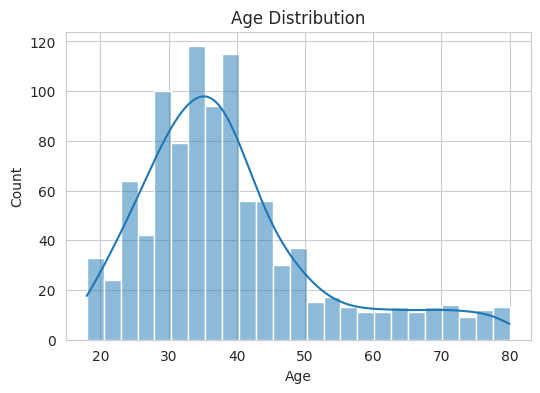

In [11]:
# Visualizing distribution of Age
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=25, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

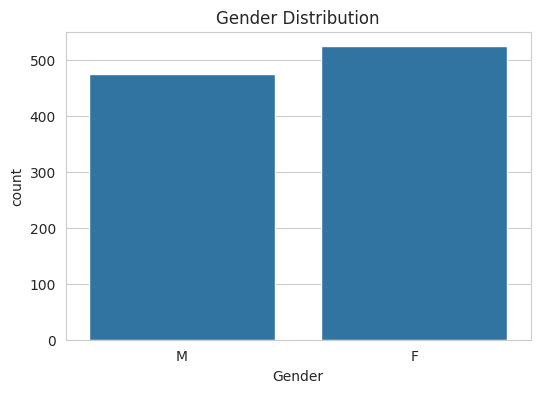

In [12]:
# Visualizing Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

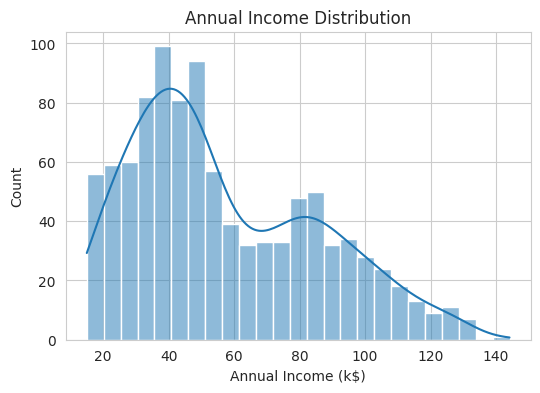

In [13]:
# Visualizing distribution of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=25, kde=True)
plt.title("Annual Income Distribution")
plt.show()

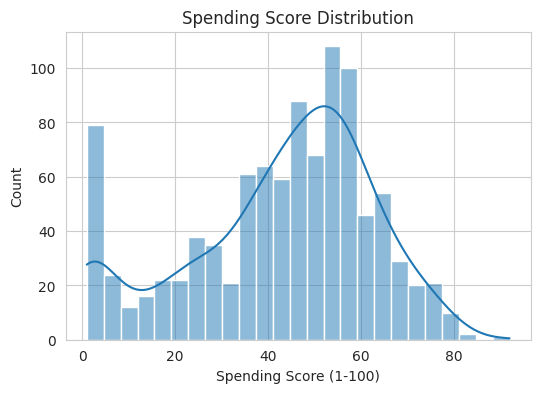

In [14]:
# Visualizing distribution of Spending Score
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=25, kde=True)
plt.title("Spending Score Distribution")
plt.show()

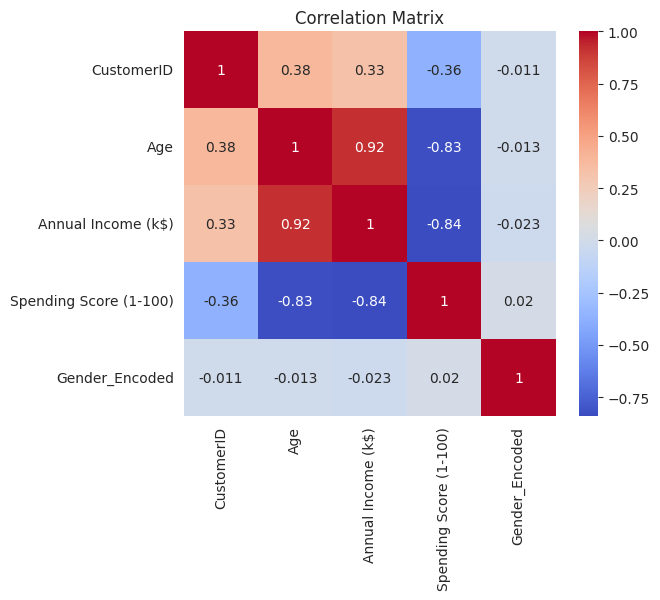

In [15]:
# Checking correlation between numeric features
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

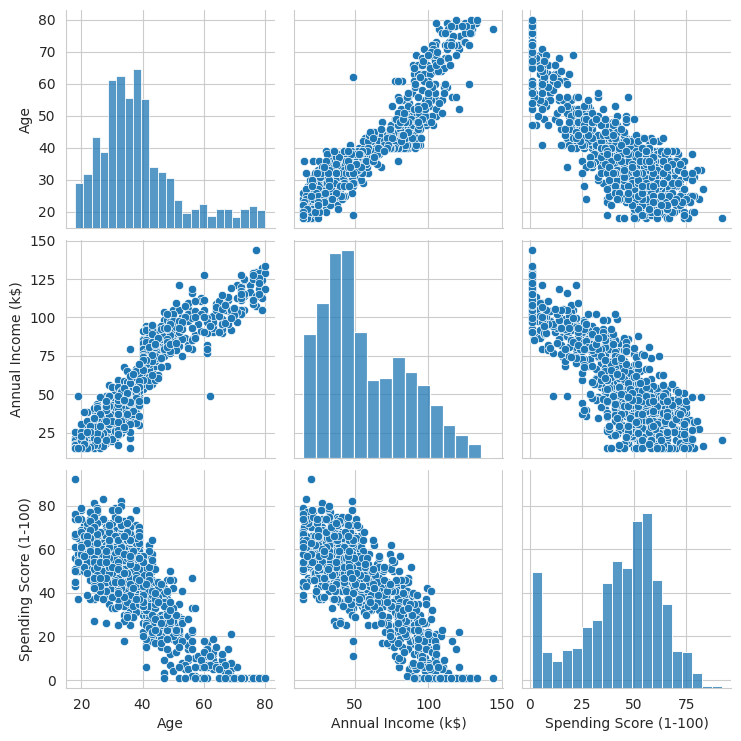

In [16]:
# Visualizing pairwise relationships between features
sns.pairplot(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])
plt.show()

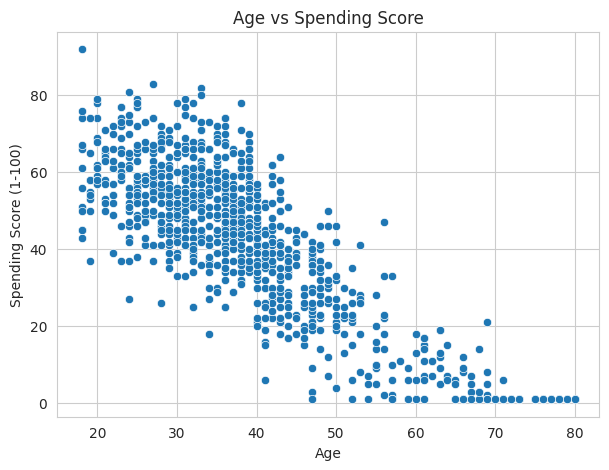

In [17]:
# Checking relationship between Age and Spending Score
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age", y="Spending Score (1-100)", data=df)
plt.title("Age vs Spending Score")
plt.show()

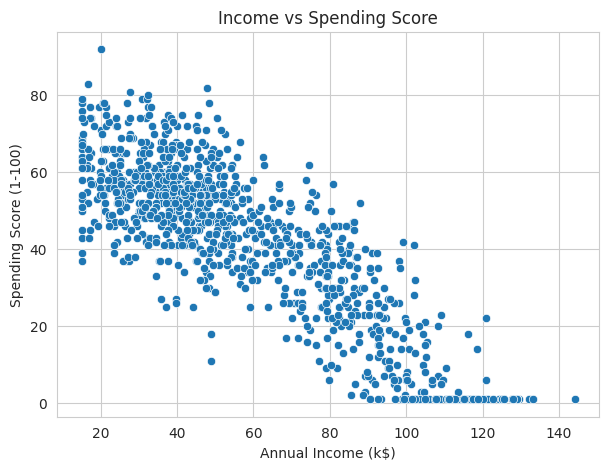

In [18]:
# This plot helps visually judge how many natural customer groups exist
plt.figure(figsize=(7,5))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)
plt.title("Income vs Spending Score")
plt.show()

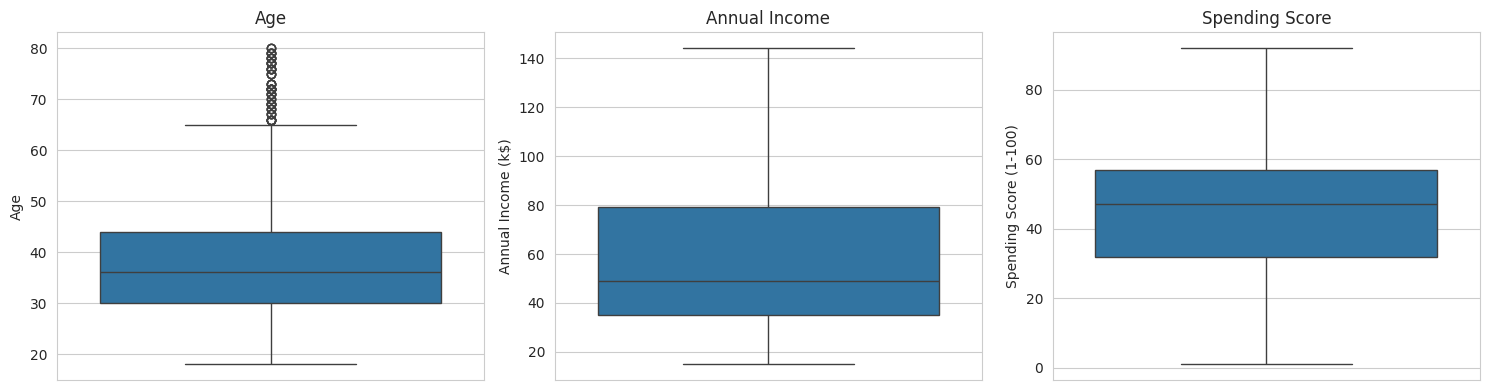

In [19]:
# Checking for outliers in Age, Income, and Spending Score
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(y=df["Age"])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(y=df["Annual Income (k$)"])
plt.title("Annual Income")

plt.subplot(1,3,3)
sns.boxplot(y=df["Spending Score (1-100)"])
plt.title("Spending Score")

plt.tight_layout()
plt.show()

In [20]:
# Getting average values of numeric features
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

Age                       38.9180
Annual Income (k$)        57.1165
Spending Score (1-100)    42.6720
dtype: float64

## Observations

- The dataset contains customers of different age groups.
- Annual income is distributed across low, medium, and high-income customers.
- Spending scores vary significantly, indicating different purchasing behaviors.
- No strong linear correlation exists among the numerical features.
- The scatter plot of Annual Income vs Spending Score shows customers forming visually 
  separable groups, confirming that K-Means clustering is a suitable approach for this data.

## Model Used

I choose **K-Means Clustering** for this project because:
- It performs well on numeric, continuous features like Income and Spending Score.
- It works best for compact, roughly spherical clusters — which matches the pattern I see 
  in the Income vs Spending Score scatter plot.
- I select Annual Income and Spending Score as the clustering features since they are the 
  most business-relevant for segmenting customers by purchasing behavior.

In [21]:
# Selecting scaled Income and Spending Score for clustering
X = scaled_df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.097456,0.765102
1,-0.305184,-0.283120
2,0.468586,-0.832188
3,0.839715,-0.632527
4,-0.525761,0.765102


## Training Process

1. I use the **Elbow Method** to find the optimal K by training K-Means for K = 1 to 10 
   and recording the WCSS (Within-Cluster Sum of Squares).
2. I also check the Silhouette Score for each K to confirm the best choice.
3. I train the final model with the chosen K, `init="k-means++"`, and `random_state=42`.
4. I assign cluster labels to each customer and compute the centroids.

In [22]:
# Running K-Means for K=1 to 10 to apply the Elbow Method
wcss = []
sil_scores = {}

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    if i > 1:
        sil_scores[i] = silhouette_score(X, kmeans.labels_)

print("Silhouette scores for each K:")
for k, s in sil_scores.items():
    print(f"K={k}: {s:.3f}")

Silhouette scores for each K:
K=2: 0.580
K=3: 0.474
K=4: 0.393
K=5: 0.366
K=6: 0.349
K=7: 0.372
K=8: 0.359
K=9: 0.353
K=10: 0.348


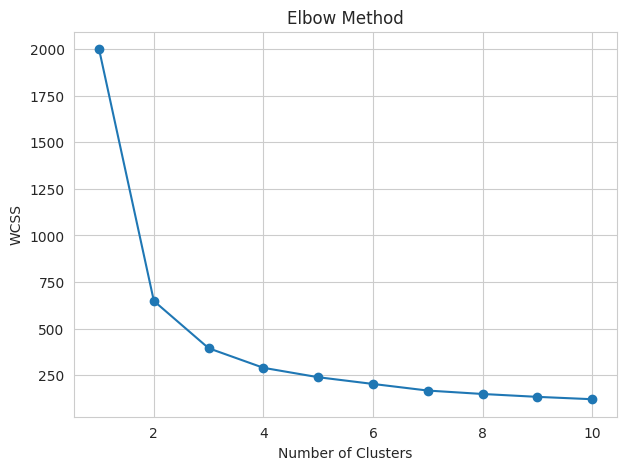

In [23]:
# Plotting WCSS to visualize the elbow point
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

## Observation

The Elbow Method shows a sharp decrease in WCSS from K = 1 to K = 3. After K = 3, the curve 
starts to flatten, indicating diminishing returns from adding more clusters. This is also 
supported by the Silhouette Scores, where K = 3 gives one of the highest and most stable 
scores among practical cluster counts. Therefore, the optimal number of clusters selected 
for this project is **K = 3**.

In [24]:
# Training final K-Means model with K=3
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,Cluster
0,1000,M,39.0,59.9,58.0,1,0
1,1001,M,34.0,48.4,37.0,1,2
2,1002,F,40.0,70.5,26.0,0,2
3,1003,F,47.0,81.1,30.0,0,2
4,1004,F,33.0,42.1,58.0,0,0


In [25]:
# Converting cluster centroids back to original scale for interpretability
centers = scaler.inverse_transform(
    np.column_stack([
        np.zeros(3),
        kmeans.cluster_centers_
    ])
)
centers

array([[ 38.918     ,  35.33187856,  56.99620493],
       [ 38.918     , 102.36630435,   9.38586957],
       [ 38.918     ,  68.03183391,  37.74394464]])

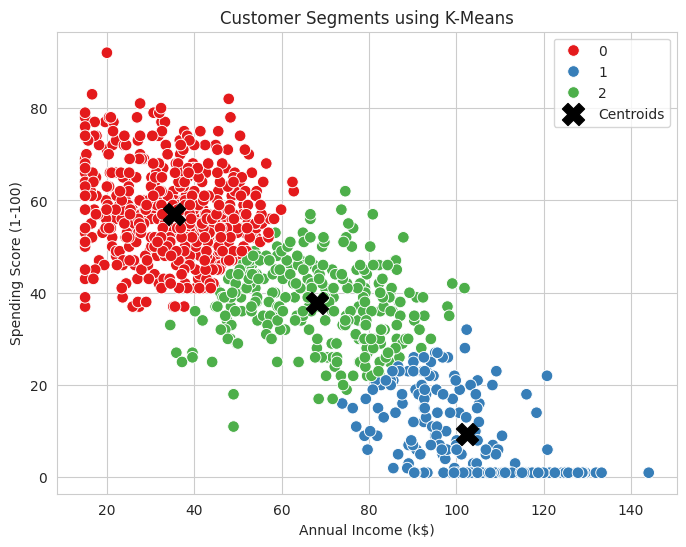

In [26]:
# Visualizing final clusters with centroids marked
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=70
)

plt.scatter(
    centers[:,1],
    centers[:,2],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [27]:
# Checking number of customers in each cluster
df["Cluster"].value_counts().sort_index()

Cluster
0    527
1    183
2    290
Name: count, dtype: int64

## Cluster Analysis

The average values of Age, Annual Income, and Spending Score for each cluster are analyzed 
to understand the characteristics of the different customer segments.

In [28]:
# Getting average Age, Income, and Spending Score per cluster
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,30.149905,35.331879,56.996205
1,61.114754,102.474863,9.316940
2,40.844828,68.081724,37.689655


## Evaluation Metrics and Results

Since there are no ground-truth labels, classification metrics don't apply here. I use 
clustering-specific metrics instead:
- **Silhouette Score**: measures cluster cohesion & separation (higher is better, range -1 to 1).
- **Davies-Bouldin Index**: measures average similarity between clusters (lower is better).

In [29]:
# Calculating Silhouette Score to evaluate cluster quality
silhouette = silhouette_score(X, df["Cluster"])
print("Silhouette Score :", round(silhouette, 3))

Silhouette Score : 0.474


In [30]:
# Calculating Davies-Bouldin Index to evaluate cluster separation
db = davies_bouldin_score(X, df["Cluster"])
print("Davies-Bouldin Index :", round(db, 3))

Davies-Bouldin Index : 0.72


In [31]:
# Viewing sample customers from each cluster
for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(df[df["Cluster"] == cluster].head())


Cluster 0
   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
4        1004      F  33.0                42.1                    58.0   
5        1005      M  33.0                36.7                    73.0   
8        1008      F  31.0                42.3                    43.0   
9        1009      M  39.0                48.6                    61.0   

   Gender_Encoded  Cluster  
0               1        0  
4               0        0  
5               1        0  
8               0        0  
9               1        0  

Cluster 1
     CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
20         1020      F  47.0                89.0                    23.0   
40         1040      M  41.0                87.7                    16.0   
71         1071      F  47.0                89.1                     3.0   
73         1073      M  48.0                98.1       

In [32]:
# Assigning business-friendly names to each cluster
cluster_labels = {
    0: "Young, Moderate Income, High Spenders",
    1: "Older, High Income, Low Spenders",
    2: "Middle-Aged, Moderate-High Income, Average Spenders"
}

df["Segment"] = df["Cluster"].map(cluster_labels)
df[["Cluster", "Segment"]].drop_duplicates().sort_values("Cluster")

,Cluster,Segment
0,0,"Young, Moderate Income, High Spenders"
20,1,"Older, High Income, Low Spenders"
1,2,"Middle-Aged, Moderate-High Income, Average Spe..."


## Cluster Interpretation

Based on the cluster centroids and average feature values, the three customer segments are 
interpreted as follows:

- **Cluster 0 – Young, Moderate Income, High Spenders:** Average age around 30, moderate 
  income (~$35k), but high spending score (~57). These are likely younger, trend-driven 
  customers who spend actively despite moderate income — good targets for loyalty programs 
  and trend-based promotions.
- **Cluster 1 – Older, High Income, Low Spenders:** Average age around 61, high income 
  (~$102k), but very low spending score (~9). These customers earn well but spend very 
  little in the mall — potential targets for re-engagement or premium/exclusive offers to 
  encourage more spending.
- **Cluster 2 – Middle-Aged, Moderate-High Income, Average Spenders:** Average age around 
  41, moderate-high income (~$68k), and average spending score (~38). This is the largest 
  and most typical customer segment, suitable for general marketing campaigns.

These insights allow the business to design differentiated marketing strategies instead of 
a one-size-fits-all approach.

# Conclusion

The K-Means clustering algorithm successfully segmented customers into **three meaningful 
groups** based on Annual Income and Spending Score.

The Elbow Method, supported by Silhouette Scores across different values of K, indicated 
that three clusters provide the best balance between simplicity, compactness, and 
separation for this dataset.

The Silhouette Score (0.474) and Davies-Bouldin Index (0.720) confirm that the clusters are 
reasonably well-defined and well-separated.

Each cluster represents a distinct customer segment with different income and spending 
patterns, which can help the business design targeted marketing strategies — such as 
loyalty programs for high spenders, re-engagement campaigns for high-income low spenders, 
and general campaigns for the average customer segment.

## References

1. Kaggle – Mall Customer Segmentation Dataset - https://www.kaggle.com/datasets/hosseinbadrnezhad/mall-customer-segmentation-dataset
2. Scikit-learn Documentation – https://scikit-learn.org/stable/modules/clustering.html#k-means
3. Pandas Documentation – https://pandas.pydata.org/
4. Matplotlib Documentation – https://matplotlib.org/
5. Seaborn Documentation – https://seaborn.pydata.org/